In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [66]:
data = pd.read_csv('e3-prelim3.csv')

In [67]:
data.columns

Index(['# Time (s)', 'Altitude (m)', 'Vertical velocity (m/s)',
       'Total velocity (m/s)', 'Vertical acceleration (m/s²)',
       'Total acceleration (m/s²)', 'Position East of launch (m)',
       'Position North of launch (m)', 'Lateral distance (m)',
       'Roll rate (°/s)', 'Pitch rate (°/s)', 'Yaw rate (°/s)', 'Mass (g)',
       'Motor mass (g)', 'Air temperature (°C)', 'Air pressure (mbar)',
       'Mach number (​)'],
      dtype='object')

In [68]:
#define constants
#air vars
gamma = 1.4
cp_air = 1005
initial_wall_temp = 300 #kelvin

#material vars
cp_fg = 900 #[J/kg*K] https://www.matweb.com/search/datasheet.aspx?MatGUID=462fd1da8ad245b2ad40093889016448&ckck=1
rho_fg = 2540  #[kg/m^3] #https://www.matweb.com/search/datasheet.aspx?MatGUID=462fd1da8ad245b2ad40093889016448&ckck=1
k_fg = .3 #[W/m*k]
cp_steel = 510 #[J/kg*K]
rho_steel = 7950 #[kg/m^3]
k_steel = 15 #[W/m*k]
emissitivity_fg = 0.75  #https://ennologic.com/wp-content/uploads/2018/07/Ultimate-Emissivity-Table.pdf
emissitivity_steel = 0 #

#nosecone vars
radius_nosecone = 0.1016 #[m]
length_nosecone = 1.016 #[m]
halfAngle = np.arctan(radius_nosecone/length_nosecone)
d = .00635 # [m] nosecone thickness 
th = d * np.cos(halfAngle) #[m] radial thickness

# Initialize
dx = .01 #[m] Set manually
x_fg = .2032 #[m] X position where steel ends and fiberglass starts
L = 10 #[m] total length of nosecone slant (including steel and fiber glass)
N = int(L/dx) + 1 #Total nodes ~ N[0] = very tip of nosecone
T_initial = 300 # [K] initial temperature of the entire nosecone

#radiation vars
boltz = 5.67*10**-8

In [72]:
def Ac(x):
    Ac = np.pi * (2* x * th * np.sin(halfAngle) - th ** 2)
    return Ac
def Ac_steel(x):
    Ac = np.pi * (x ** 2) * (np.sin(halfAngle)) ** 2
    return Ac
def dAs(x, xplusdx):
    As = np.pi * np.sin(halfAngle) * ( xplusdx ** 2 - x ** 2 )
    return As
dAs0 = np.pi * np.sin(halfAngle) * ( 0.5 * dx ) ** 2
def dV(x, xplusdx):
    dh = (xplusdx - x) * np.cos(halfAngle)
    r_m1 = xplusdx * np.sin(halfAngle)
    r_m = x * np.sin(halfAngle)
    r_m1t = r_m1 - th
    r_mt = r_m - th
    dVolume = 1/3 * np.pi * dh * ( (r_m1**(2) + r_m * r_m1 + r_m**(2)) - ( r_m1t**(2) + r_mt * r_m1t + r_mt**(2)) )
    #print(f"r_m1: {r_m1}, r_m: {r_m}, r_m1t: {r_m1t}, r_mt: {r_mt}, dh: {dh}")
    dV = np.float64(dVolume)
    #print(dV)
    return dV
def dV_steel(x, xplusdx):
    dV_steel = 1/3 * np.pi * (np.sin(halfAngle)) ** 2 * np.cos(halfAngle) * ( xplusdx ** 3 - x ** 3)
    return dV_steel

In [73]:
def q_convection(row, temp_wall, x):
    #calculate air density
    rho_air = row['Air pressure (mbar)']*100/(0.287*(row['Air temperature (°C)']+273.15))/1000
    # print(rho_air)

    #calculate static pressure
    Tstag_air = (1+(gamma-1)/2*row['Mach number (​)']**2)*(row['Air temperature (°C)']+273.15)
    # print(Tstag_air)

    #freestream enthalpy
    h_air = Tstag_air*cp_air
    # print(h_air)

    #h_aw
    h_aw = h_air + 0.4*row['Total velocity (m/s)']**2
    # print(h_aw)

    #wall enthalpy
    h_wall = temp_wall*cp_fg if x > x_fg else temp_wall * cp_steel
    # print(h_wall)

    # if x>x_fg:
        # print(f"ratio:{h_wall/h_aw}")

    #heat per unit area
    q = (4.03*10**-5)*(rho_air*np.cos(halfAngle)/(x + .5*dx))**(1/2)*(row['Total velocity (m/s)']**3.2)*np.sin(halfAngle)*(1-h_wall/h_aw) # W/m^2
    return q

In [79]:
T = np.ones(N) * T_initial #[K] set all nodes temperature to initial
history = [T.copy()]

for t in range(0, data.shape[0]-1): # go through every row (time index)
    dt = data['# Time (s)'][t+1] - data['# Time (s)'][t]
    Tm = T.copy()

    # Calculate Node 0 (very tip) first, then rest of the nodes
    for m in range(0, N-1): #node index
        if m == 0: # very tip
            x = m # x = 0
            T[0] = Tm[0] + dt / (rho_steel * cp_steel * dV_steel(x, x + 0.5 * dx)) * (k_steel * Ac_steel(x+.5*dx) / dx * (Tm[m+1] - Tm[m]) + q_convection(data.loc[t], Tm[0], x) * dAs0)
            
        else:
            x = dx * (m - 0.5)
            if x < x_fg: #steel tip
                T[m] = Tm[m] + dt / (rho_steel * cp_steel * dV_steel(x, x + dx)) * (k_steel / dx * (Ac_steel(x) * (Tm[m-1] - Tm[m]) +  Ac_steel(x+dx) * (Tm[m+1] - Tm[m])) + q_convection(data.loc[t], Tm[m], x) * dAs(x,x+dx))
                #T[m] = Tm[m] + dt / (rho_steel * cp_steel * dV_steel(x,x+dx)) * q_convection(data.loc[t],Tm[m],x) * dAs(x,x+dx)
            elif x >= x_fg: #fiberglass part
                #T[m] = Tm[m] + dt / (rho_fg * cp_fg * dV(x, x+dx)) * (k_fg / dx * (Ac(x) * (Tm[m-1] - Tm[m]) + Ac(x+dx) * (Tm[m+1] - Tm[m])) + q_convection(data.loc[t], Tm[m], x) * dAs(x,x+dx))
                # T[m] = Tm[m] + dt / (rho_fg * cp_fg * dV(x, x+dx)) * (k_fg / dx * (Ac(x) * (Tm[m-1] - Tm[m]) + Ac(x+dx) * (Tm[m+1] - Tm[m])))
                # T[m] = Tm[m] + dt/(rho_fg * cp_fg * dV(x,x+dx)) * (k_fg / dx * (Ac(x) + (Tm[m-1] - Tm[m])))
                T[m] = Tm[m] + dt/ (rho_fg * cp_fg * dV(x,x+dx)) * (k_fg / dx * (Ac(x) * (Tm[m-1] - Tm[m]) + Ac(x+dx) * (Tm[m+1] - Tm[m])) + q_convection(data.loc[t],Tm[m],x) * dAs(x,x+dx))
    history.append(T.copy())

    #check for apogee
    if data['Altitude (m)'][t+1] < data['Altitude (m)'][t]:
        stop_index = t
        break


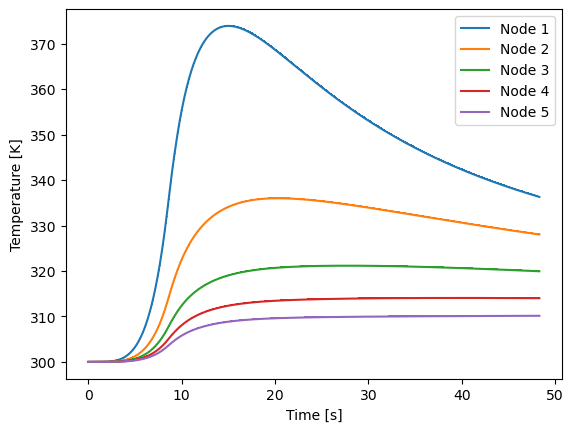

In [85]:
# Plot results in Kelvin
plot_nodes = [1, 2, 3, 4, 5]
times = np.array(data['# Time (s)'][0:stop_index][:,])
history = np.array(history[0:stop_index])
#print(history)
#print(history.shape)
#print(times)
#print('shape')
#print(times.shape)
for i in plot_nodes:
    plt.plot(times, history[:,i], marker = ',',label = f"Node {i}")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.show()

[[300.         300.         300.         ... 300.         300.
  300.        ]
 [300.         300.         300.         ... 300.         300.
  300.        ]
 [300.         300.         300.         ... 300.         300.
  300.        ]
 ...
 [339.903489   336.41774022 328.08575696 ... 300.33589907 300.31991477
  300.        ]
 [339.82262089 336.35393745 328.05539751 ... 300.33589695 300.31987306
  300.        ]
 [339.74137566 336.28977715 328.02479973 ... 300.3358948  300.31983095
  300.        ]]


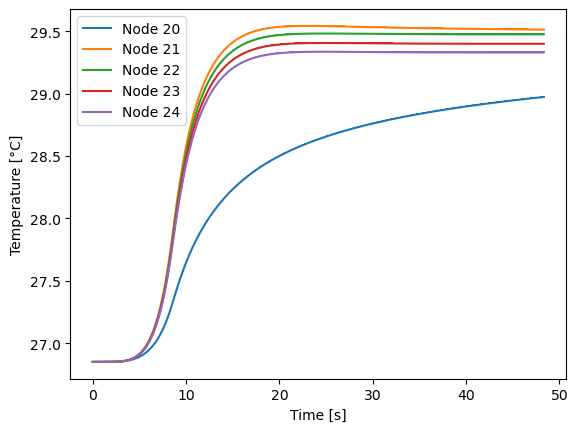

In [84]:
# Plot results in Celsius
plot_nodes = [20, 21, 22, 23, 24]
times = np.array(data['# Time (s)'][0:stop_index][:,])
history_c = np.array(history[0:stop_index]) - 273.15
#print(history)
#print(history.shape)
#print(times)
#print('shape')
#print(times.shape)
for i in plot_nodes:
    plt.plot(times, history_c[:,i], marker = ',',label = f"Node {i}")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.show()